<a href="https://colab.research.google.com/github/007arjungangwar/Foundations-of-Data-Engineering-Sec2/blob/main/%F0%9F%94%8AWorking_and_Understanding_the_Audio_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔊 Working with Audio in Python

<img src="https://miro.medium.com/max/1100/1*Zx9QAMPzxhama9O4q9xWXg.jpeg" width="600"/>

This notebook is intended to be an introduction for anyone interested in using python to interperate audio data.


In [94]:
!pip install librosa soundfile matplotlib

In [2]:
import random
import librosa
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

# Terms to know for Audio in Digital Form:

## Frequency (Hz)
- Frequency describes the differences of wave lengths.
- We interperate frequency has high and low pitches.

<img src="https://uploads-cdn.omnicalculator.com/images/britannica-wave-frequency.jpg" width="400"/>

## Intensity (db / power)
- Intensity describes the amplitude (height) of the wave.

<img src="https://ars.els-cdn.com/content/image/3-s2.0-B9780124722804500162-f13-15-9780124722804.gif" width="400"/>




## Sample Rate
- Sample rate is specific to how the computer reads in the audio file.
- Think of it as the "resolution" of the audio.


https://www.headphonesty.com/wp-content/uploads/2019/07/Sample-Rate-Bit-Depth-and-Bit-Rate.jpeg



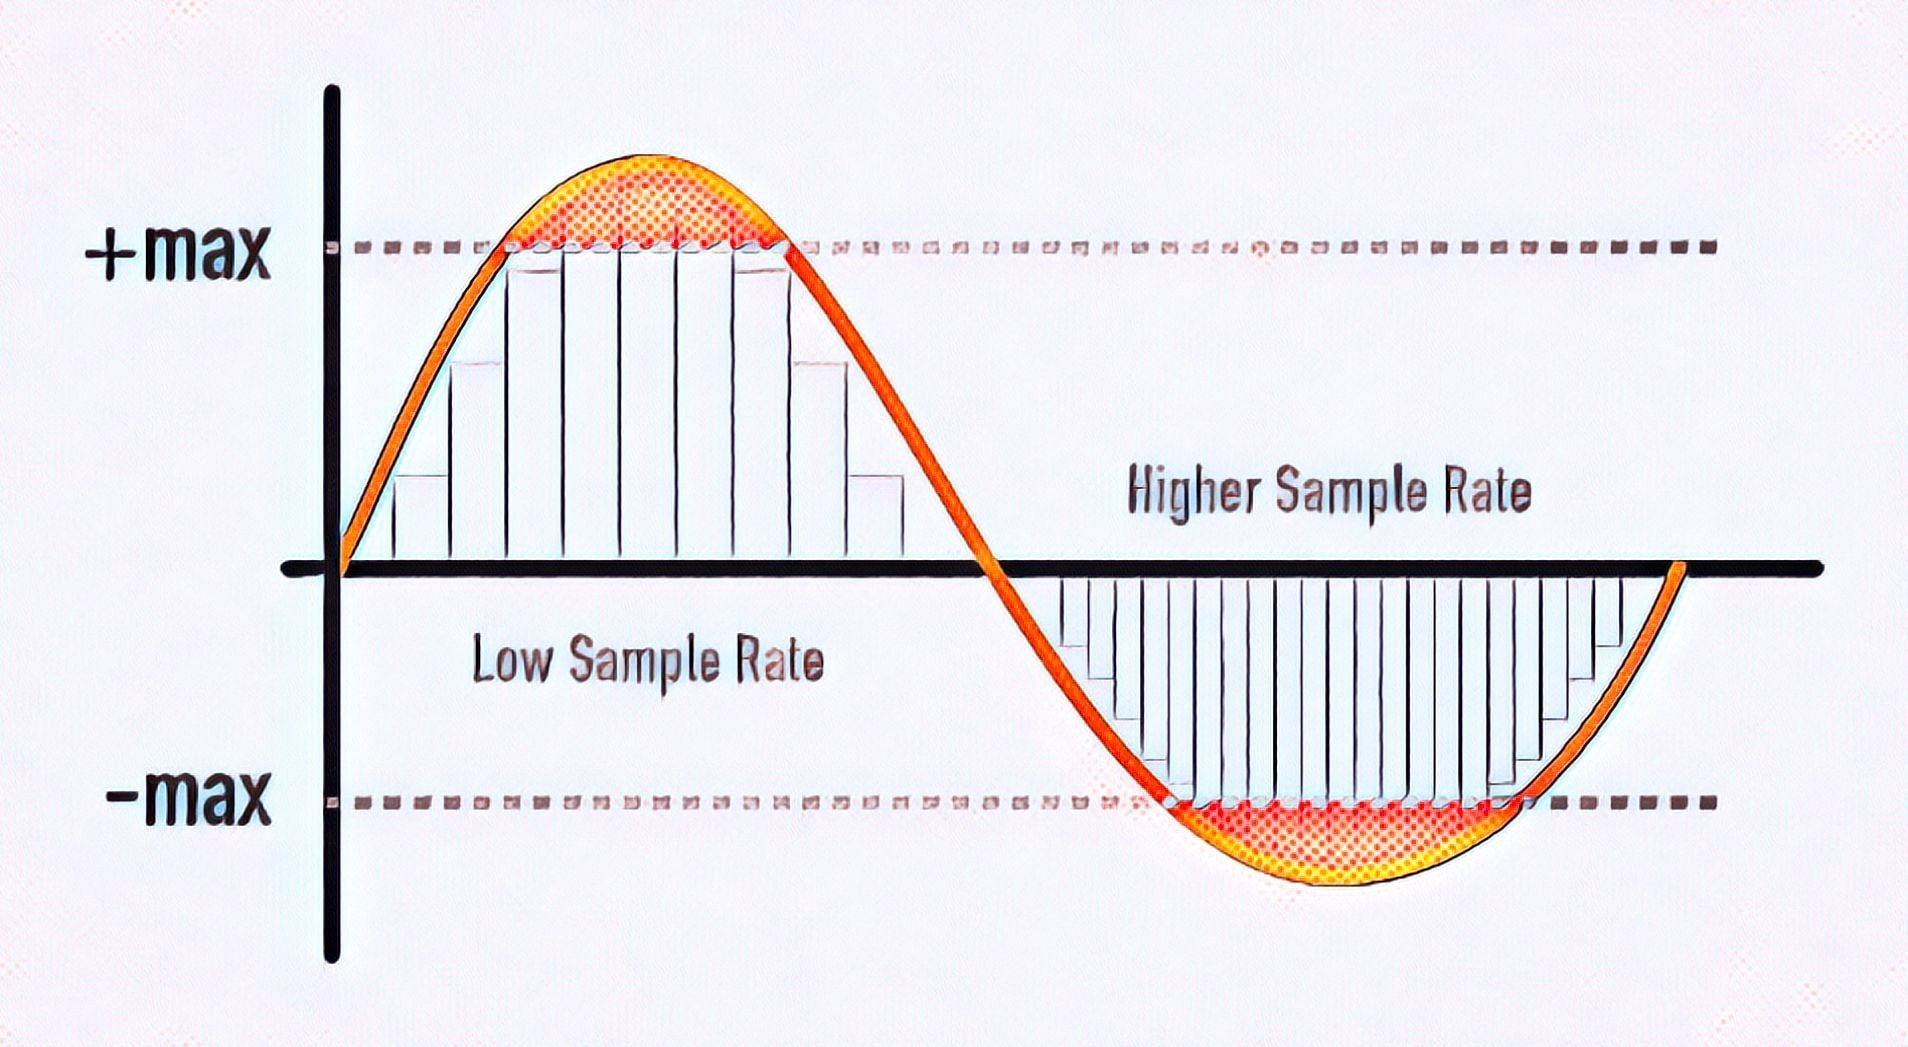

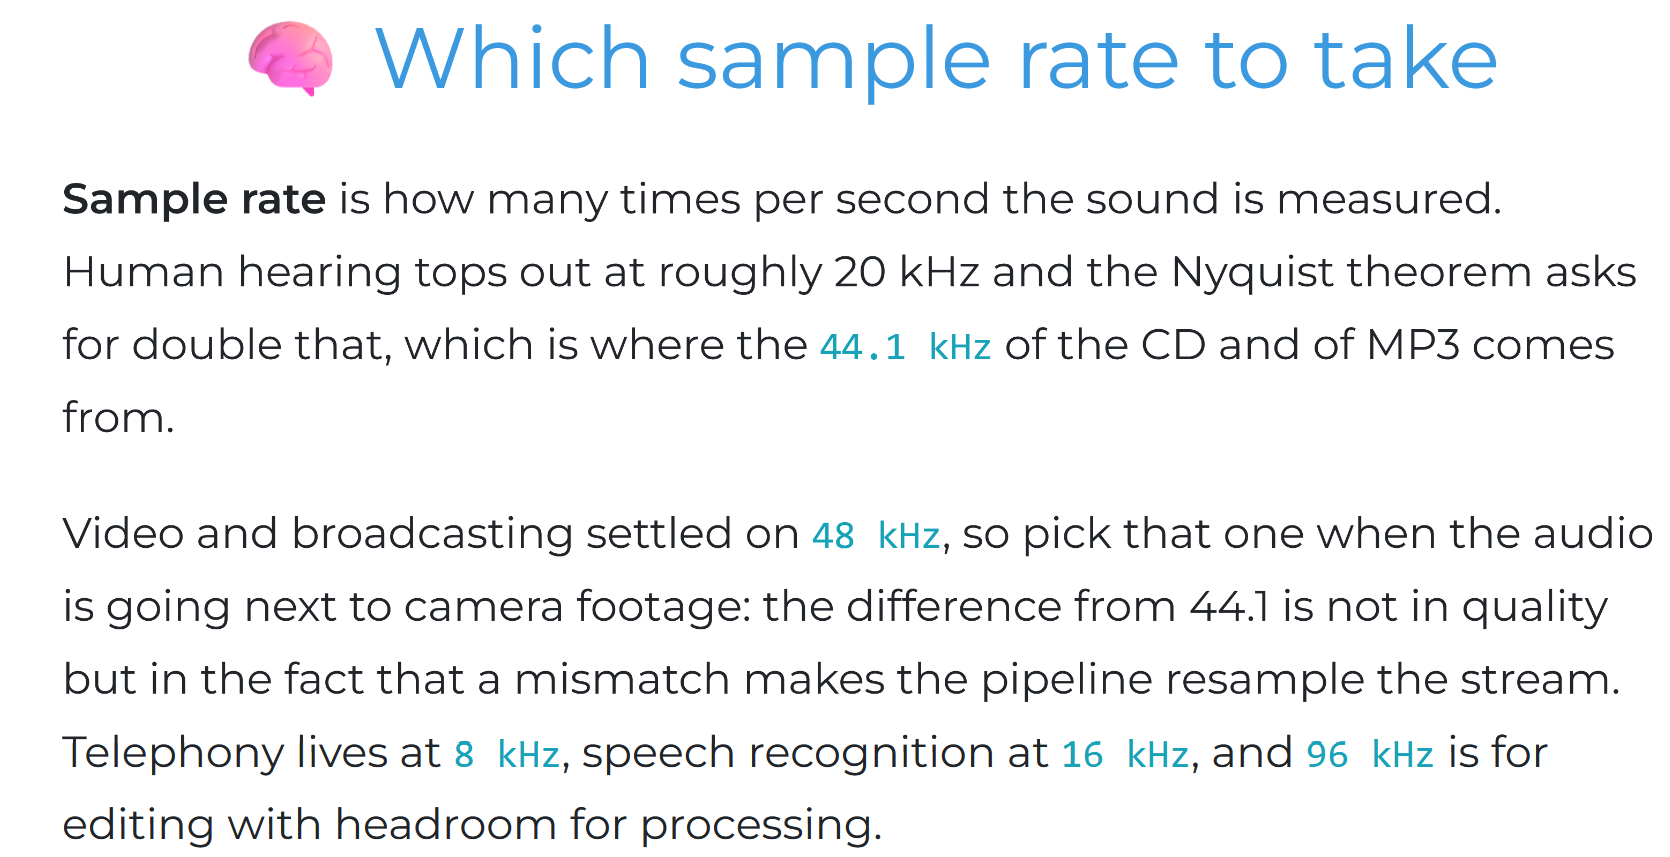

[librosa](https://librosa.org/doc/latest/index.html)


[Audiomentations](https://iver56.github.io/audiomentations/)

[Sample Audio Files for Testing](https://samplelib.com/sample-audio.html)

In [13]:
signal, sr = librosa.load("/content/CaveDrumPerc_SP_236_1.wav")

print("Sample Rate:", sr)
print("Samples:", len(signal))

Sample Rate: 22050
Samples: 48191


In [14]:
type(signal)

numpy.ndarray

In [15]:
signal.shape

(48191,)

In [16]:
print(signal)

[-2.0638108e-06  9.5516443e-06  1.0594726e-05 ...  1.1057200e-05
  8.7955050e-06  2.8439117e-06]


In [17]:
import IPython.display as ipd
# Play audio file
ipd.Audio(signal, rate=sr)

# **Load data**

In [37]:
y, sr = librosa.load("/content/CaveDrumPerc_SP_236_1.wav")
print(f'y: {y[:10]}')
print(f'shape y: {y.shape}')
print(f'sr: {sr}')

y: [-2.0638108e-06  9.5516443e-06  1.0594726e-05  1.1563301e-05
 -3.7029386e-05 -1.4661252e-04 -3.4467876e-04 -6.0856342e-04
 -9.5303357e-04 -1.2917519e-03]
shape y: (48191,)
sr: 22050


In [38]:
import IPython.display as ipd
# Play audio file
ipd.Audio(signal, rate=sr)

In [20]:
import pandas as pd

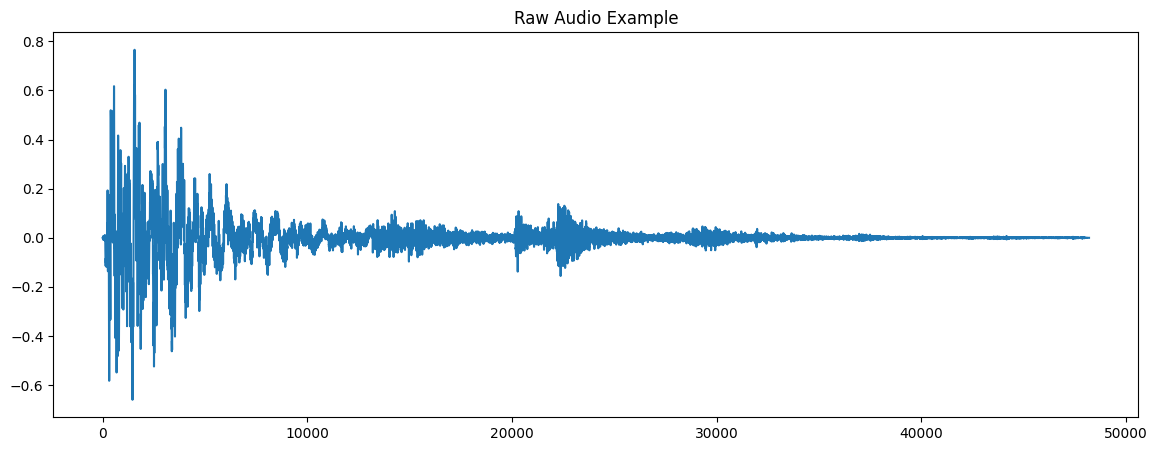

In [22]:
pd.Series(y).plot(figsize=(14, 5),title='Raw Audio Example',)
plt.show()

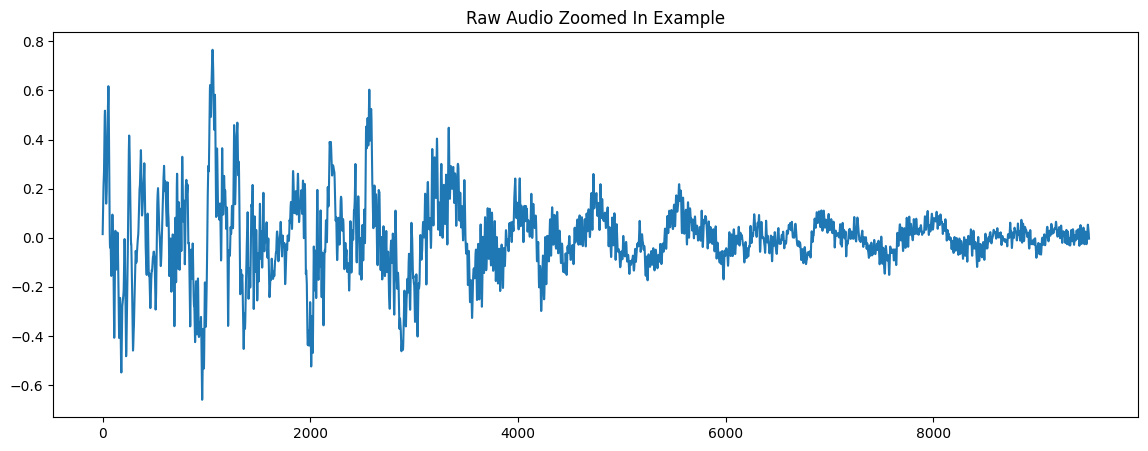

In [24]:
pd.Series(y[500:10000]).plot(figsize=(14, 5),title='Raw Audio Zoomed In Example')
plt.show()

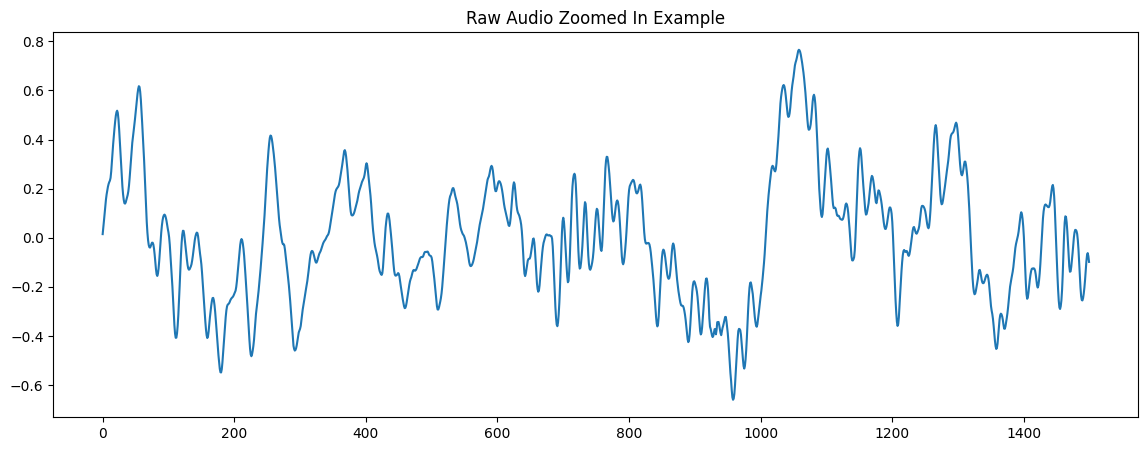

In [26]:
pd.Series(y[500:2000]).plot(figsize=(14, 5),title='Raw Audio Zoomed In Example')
plt.show()

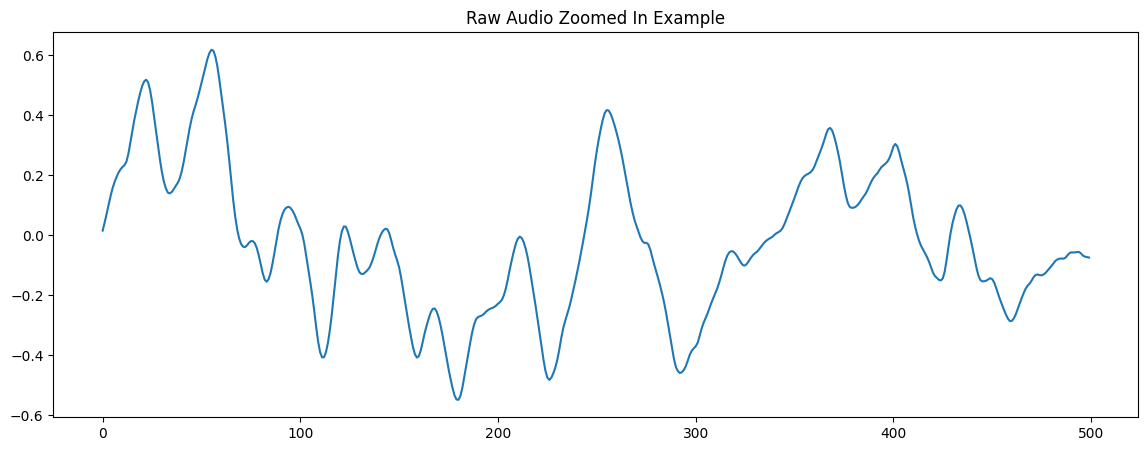

In [27]:
pd.Series(y[500:1000]).plot(figsize=(14, 5),title='Raw Audio Zoomed In Example')
plt.show()

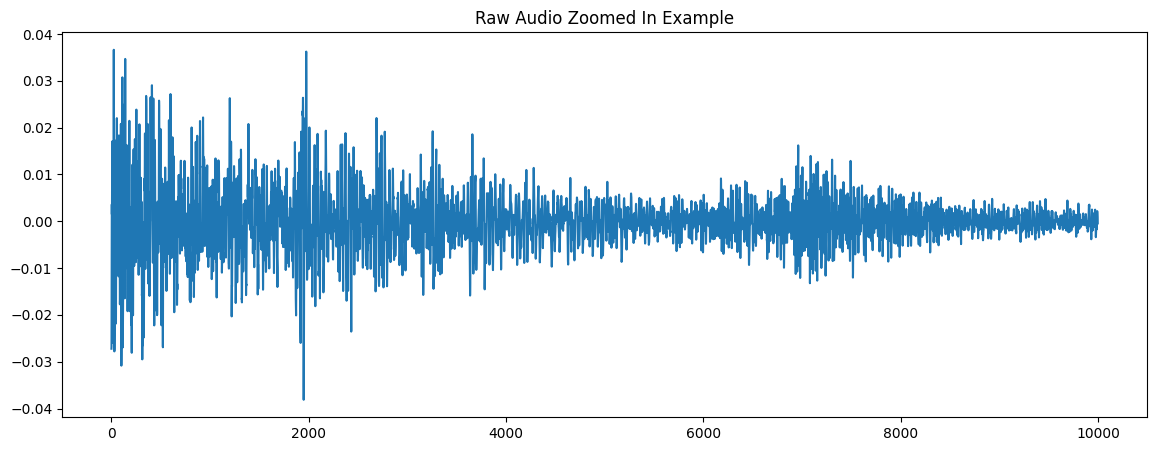

In [28]:
pd.Series(y[30000:40000]).plot(figsize=(14, 5),title='Raw Audio Zoomed In Example')
plt.show()

In [29]:
y[30000:40000]

array([-0.02722112, -0.02679232, -0.0129778 , ...,  0.00085514,
        0.00016594, -0.00046121], dtype=float32)

# **controllable parameters with different augmentation strengths.**

| Technique              | Parameter         | What you can change         |
| ---------------------- | ----------------- | --------------------------- |
| **White Noise**        | `noise_factor`    | Amount of noise             |
| **Time Stretching**    | `rate`            | Speed of audio              |
| **Pitch Shifting**     | `n_steps`         | Pitch up/down               |
| **Volume/Gain**        | `gain`            | Loudness                    |
| **Polarity Inversion** | `invert`          | Reverse amplitude           |
| **Time Shifting**      | `shift`           | Move audio left/right       |
| **Fade In**            | `duration`        | Fade-in duration            |
| **Fade Out**           | `duration`        | Fade-out duration           |
| **Clipping**           | `threshold`       | Limit amplitude             |
| **Silence Addition**   | `duration`        | Add silence                 |
| **Background Noise**   | `noise_level`     | Control background noise    |
| **Speed + Pitch**      | `rate`, `n_steps` | Change both speed and pitch |


**1. Add White Noise**

In [30]:
def add_noise(signal, factor=0.55):
    noise = np.random.normal(0, signal.std(), len(signal))
    return signal + noise * factor

In [31]:
augmented_signal = add_noise(signal)

sf.write("noise_audio.wav", augmented_signal, sr)

In [32]:
sr

22050

In [33]:
augmented_signal

array([ 0.02647243, -0.02590215,  0.0229263 , ...,  0.01353843,
        0.01430892,  0.00458713])

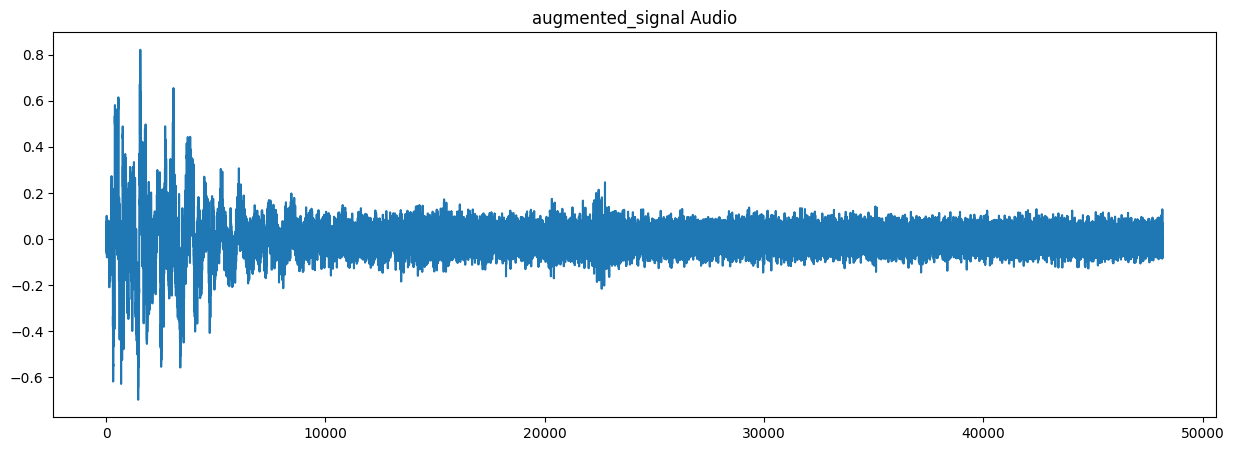

In [35]:
pd.Series(augmented_signal).plot(figsize=(15, 5),
                  title='augmented_signal Audio',)
plt.show()

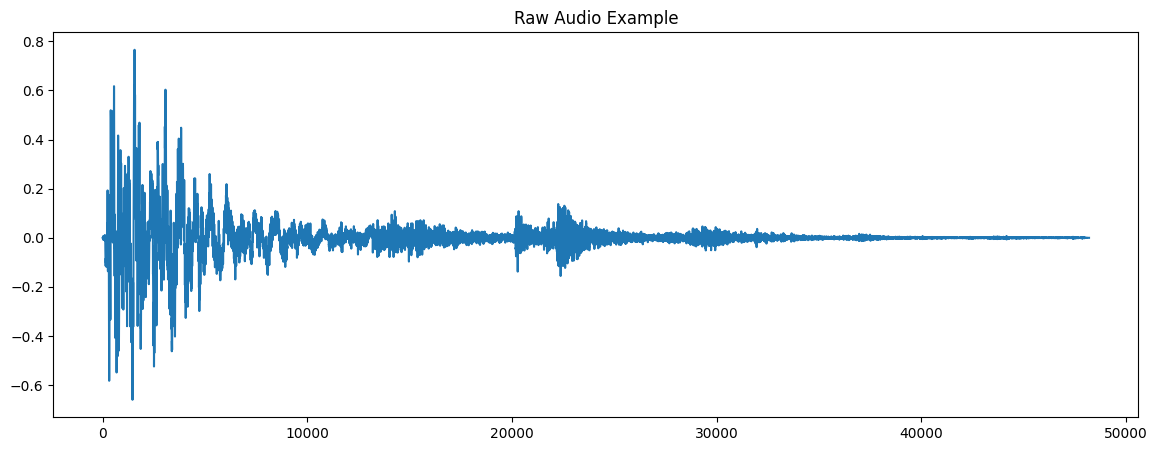

In [51]:
pd.Series(y).plot(figsize=(14, 5),title='Raw Audio Example',)
plt.show()

In [36]:
# Play audio file
ipd.Audio(augmented_signal, rate=sr)

**2. Time Stretching**

Time stretching changes the speed/duration without changing the pitch.

In [53]:
def time_stretch(signal, rate=0.2):  # rate equal to speed
    return librosa.effects.time_stretch(signal, rate=rate)

In [54]:
augmented_signal = time_stretch(signal)

sf.write("stretched_audio.wav", augmented_signal, sr)

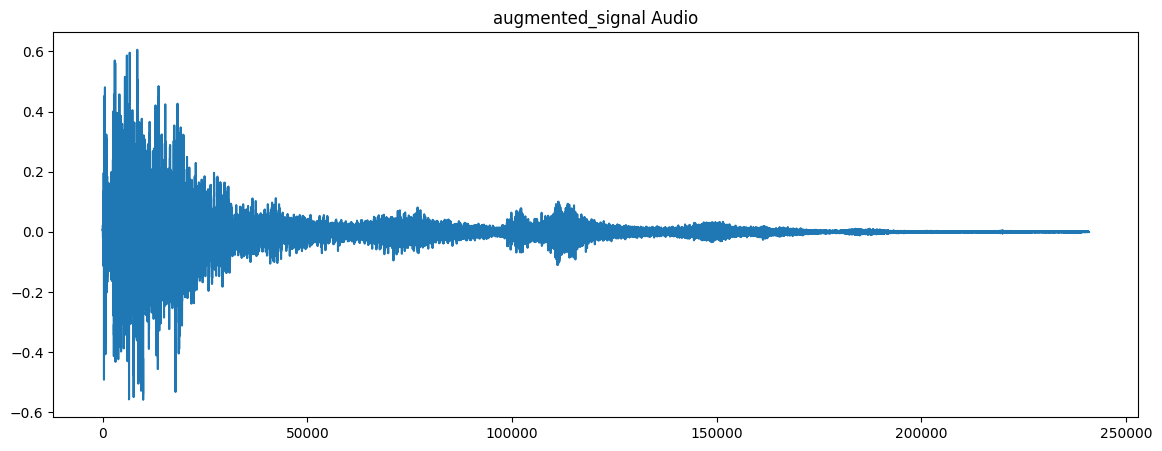

In [55]:
pd.Series(augmented_signal).plot(figsize=(14, 5),
                  title='augmented_signal Audio',)
plt.show()

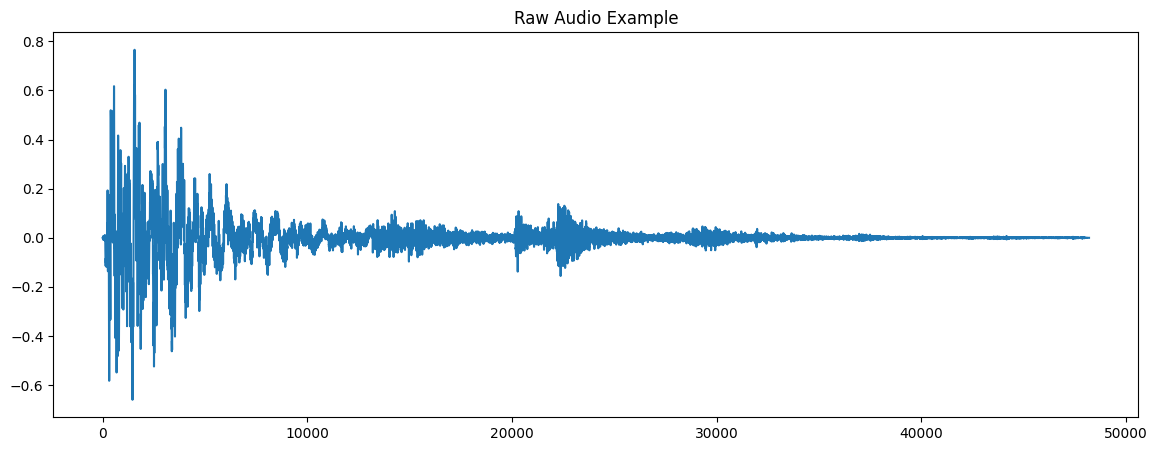

In [56]:
pd.Series(y).plot(figsize=(14, 5),title='Raw Audio Example',)
plt.show()

In [57]:
# Play audio file
ipd.Audio(augmented_signal, rate=sr)

**3. Pitch Shifting**

Pitch shifting changes the pitch without changing the duration.

In [58]:
def pitch_shift(signal, sr, steps=2):
    return librosa.effects.pitch_shift(signal,sr=sr,n_steps=steps)

In [59]:
augmented_signal = pitch_shift(signal, sr, 2)

sf.write("pitch_audio.wav", augmented_signal, sr)

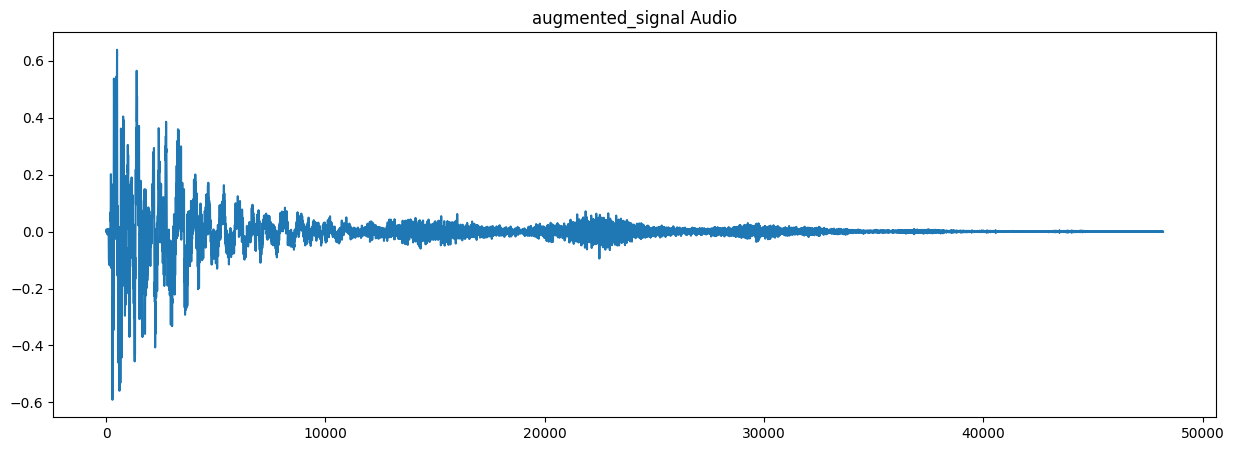

In [61]:
pd.Series(augmented_signal).plot(figsize=(15, 5),
                  title='augmented_signal Audio',)
plt.show()

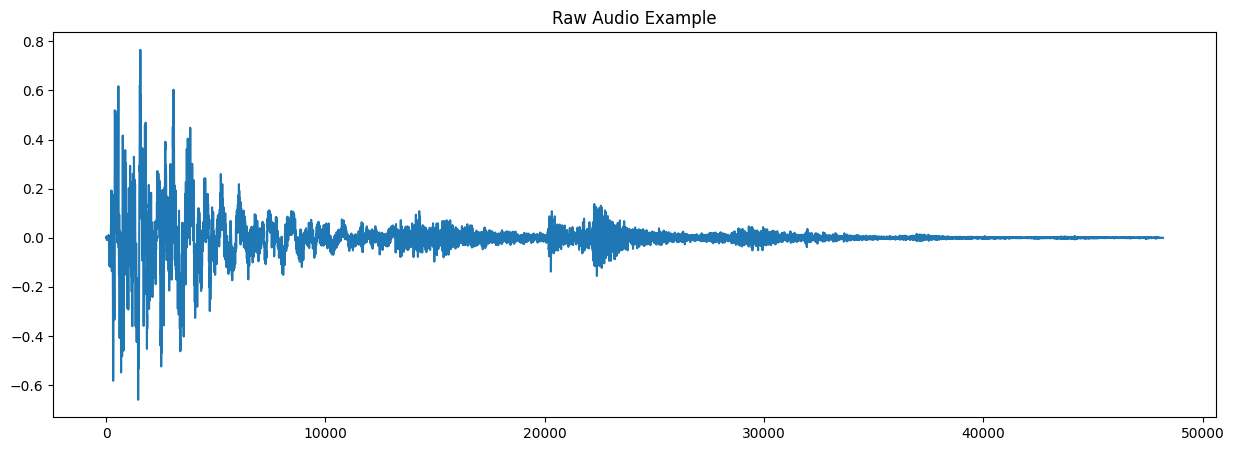

In [64]:
pd.Series(y).plot(figsize=(15, 5),title='Raw Audio Example',)
plt.show()

In [62]:
# Play audio file
ipd.Audio(augmented_signal, rate=sr)

**4. Random Gain**

Changes the volume of the audio.

In [65]:
def change_volume(signal, min_gain=0.5, max_gain=1.5):
    gain = random.uniform(min_gain, max_gain)
    return signal * gain

In [66]:
augmented_signal = change_volume(signal)

sf.write("volume_audio.wav", augmented_signal, sr)

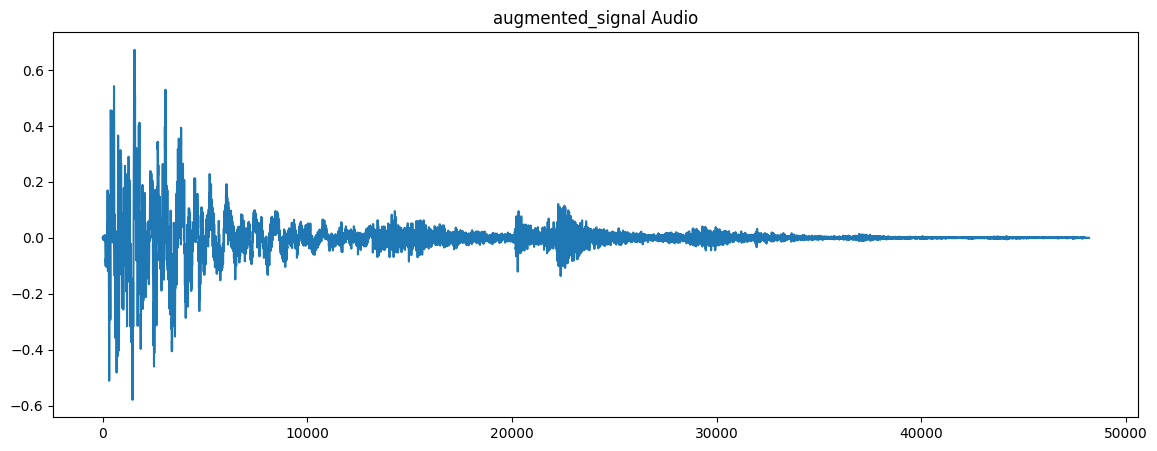

In [67]:
pd.Series(augmented_signal).plot(figsize=(14, 5),
                  title='augmented_signal Audio',)
plt.show()

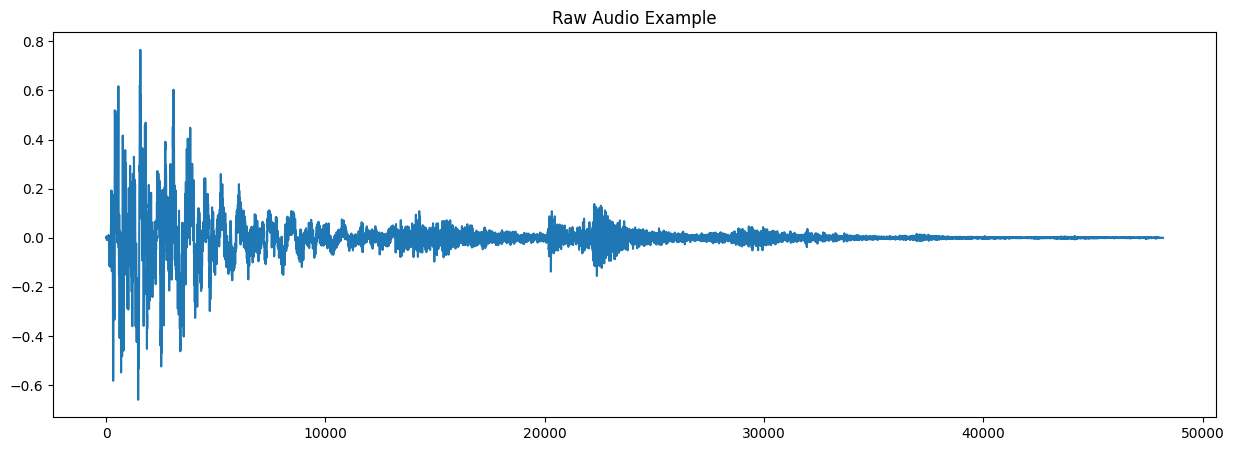

In [68]:
pd.Series(y).plot(figsize=(15, 5),title='Raw Audio Example',)
plt.show()

In [50]:
# Play audio file
ipd.Audio(augmented_signal, rate=sr)

**5. Invert Polarity**

This simply reverses the amplitude.

In [72]:
def invert_polarity(signal):
    return -signal

In [73]:
augmented_signal = invert_polarity(signal)

sf.write("inverted_audio.wav", augmented_signal, sr)

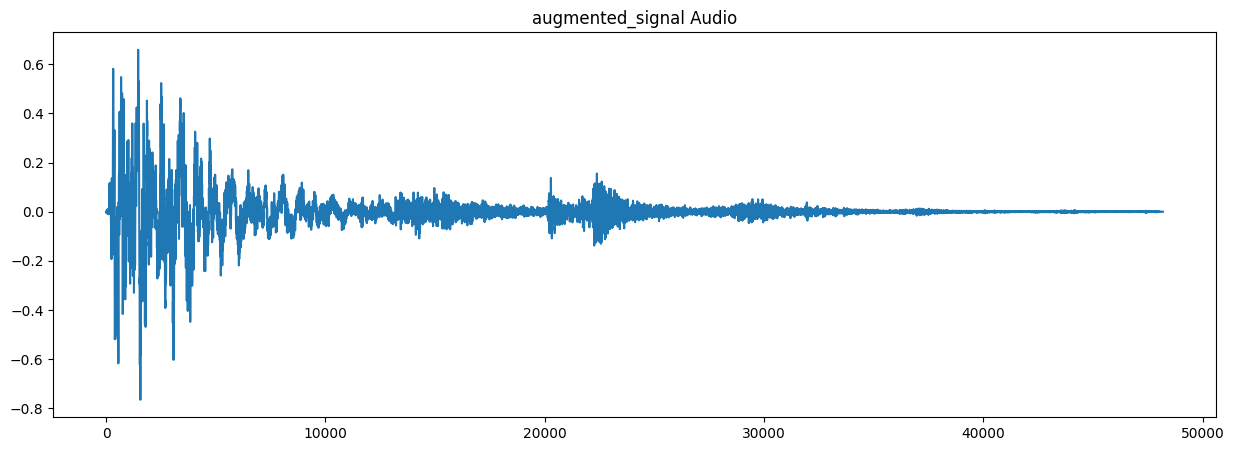

In [74]:
pd.Series(augmented_signal).plot(figsize=(15, 5),
                  title='augmented_signal Audio',)
plt.show()

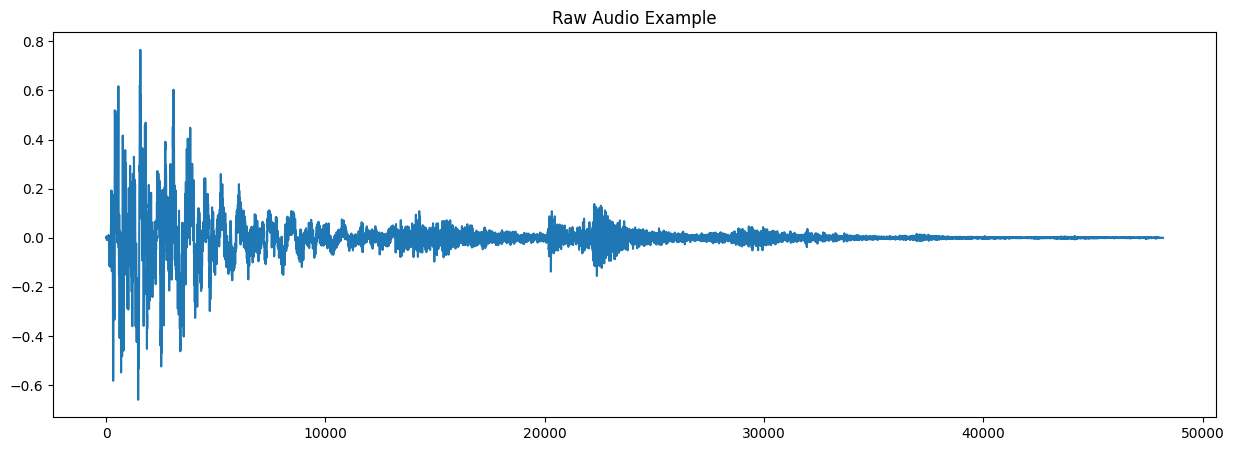

In [75]:
pd.Series(y).plot(figsize=(15, 5),title='Raw Audio Example',)
plt.show()

In [76]:
# Play audio file
ipd.Audio(augmented_signal, rate=sr)

**6. Plot Original vs Augmented Audio**

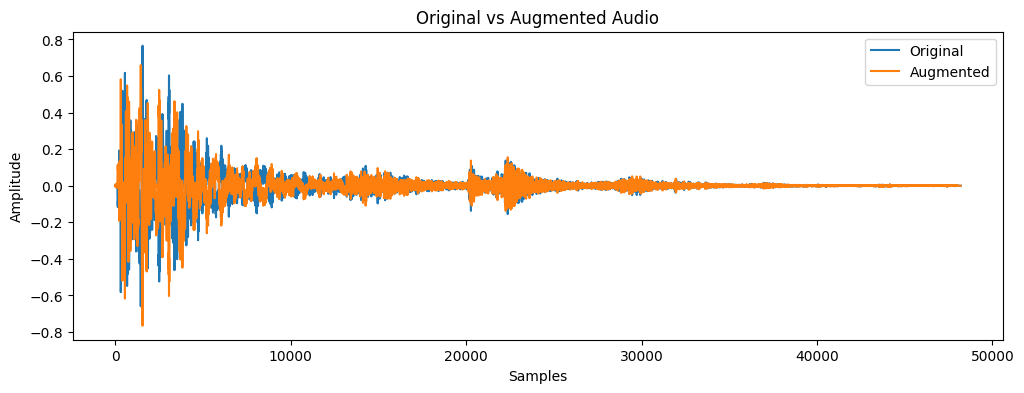

In [77]:
plt.figure(figsize=(12, 4))

plt.plot(signal, label="Original")
plt.plot(augmented_signal, label="Augmented")

plt.legend()
plt.title("Original vs Augmented Audio")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [78]:
# Play audio file
ipd.Audio(augmented_signal, rate=sr)

**7 Remix**

Remix an audio signal by re-ordering time intervals.

In [86]:
augmented_signal=librosa.effects.remix(signal,np.array([(10000,40500)]))

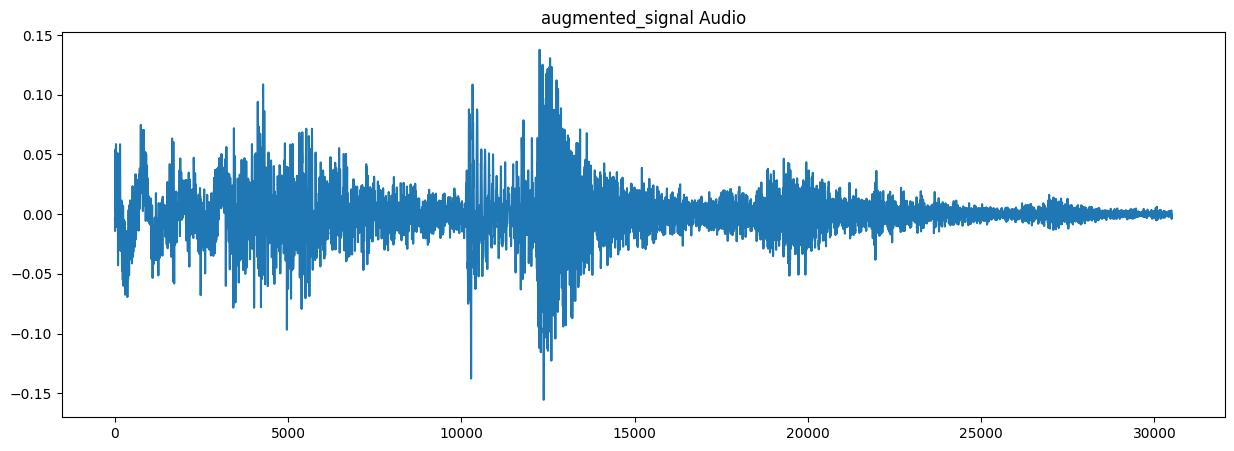

In [87]:
pd.Series(augmented_signal).plot(figsize=(15, 5),
                  title='augmented_signal Audio',)
plt.show()

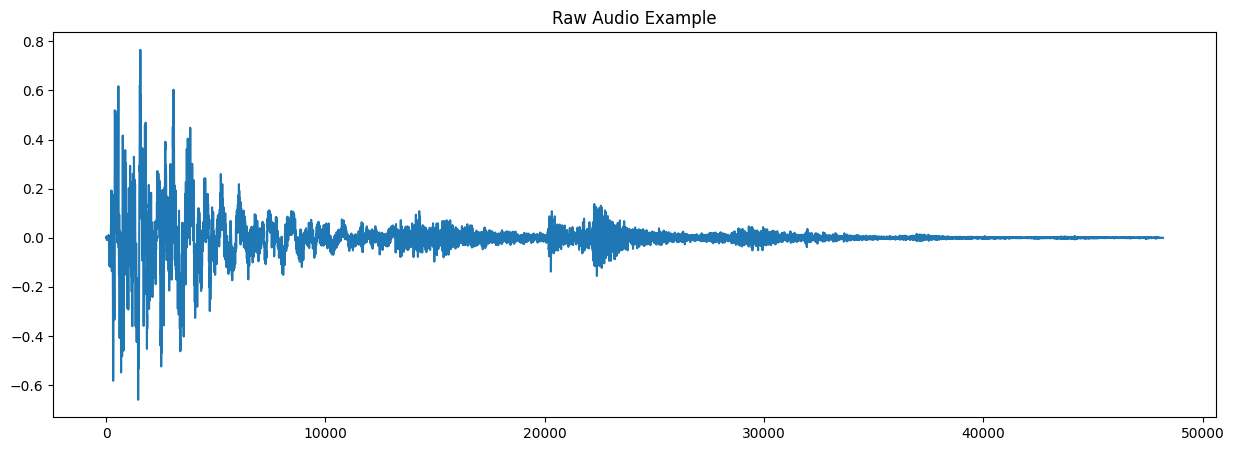

In [88]:
pd.Series(y).plot(figsize=(15, 5),title='Raw Audio Example',)
plt.show()

In [89]:
# Play audio file
ipd.Audio(augmented_signal, rate=sr)

Combine Multiple Augmentations

In [90]:
augmented = add_noise(signal, 0.05)
augmented = time_stretch(augmented, 1.2)
augmented = pitch_shift(augmented, sr, 2)
augmented = change_volume(augmented, 0.8)

In [91]:
# Play audio file
ipd.Audio(augmented, rate=sr)

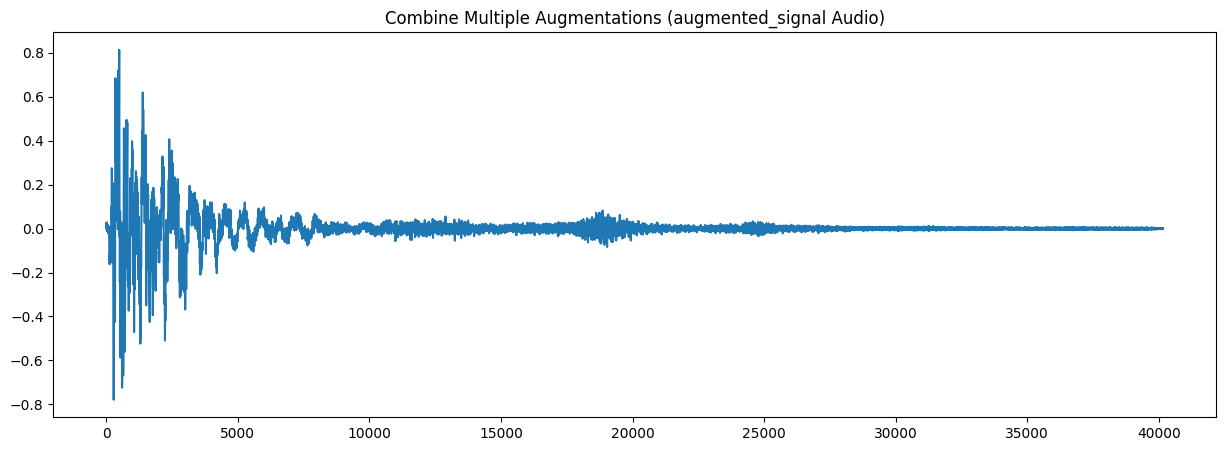

In [92]:
pd.Series(augmented).plot(figsize=(15, 5),
                  title='Combine Multiple Augmentations (augmented_signal Audio)',)
plt.show()

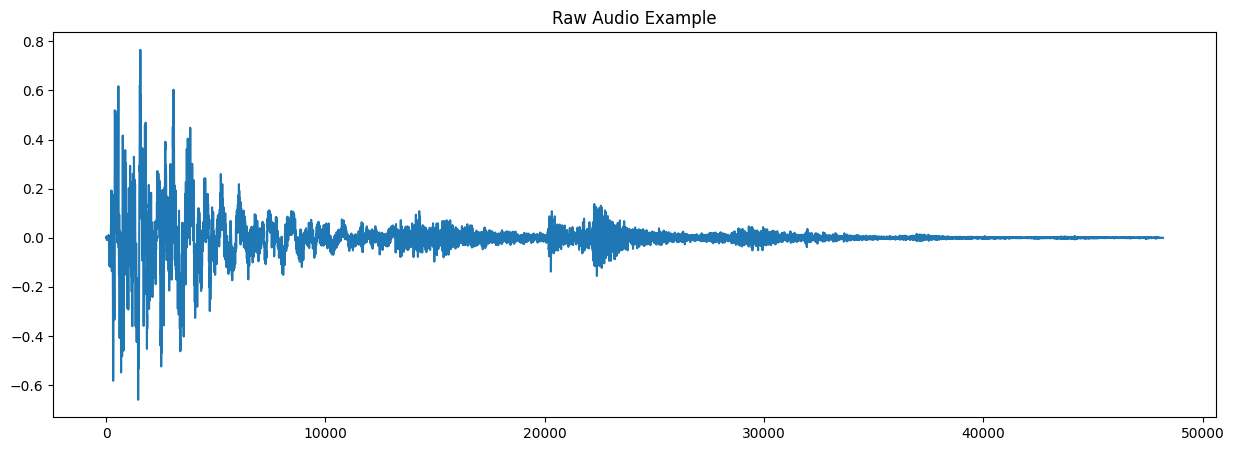

In [93]:
pd.Series(y).plot(figsize=(15, 5),title='Raw Audio Example',)
plt.show()

# Save audio

**Save the Audio file**

In [ ]:
sf.write("augmented_audio.wav", augmented, sr)

# **compact version:**

In [ ]:
import librosa
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

In [94]:
# Load audio
signal, sr = librosa.load("/content/CaveDrumPerc_SP_236_1.wav")

In [95]:
# Add noise
noise = np.random.normal(0, signal.std(), len(signal))
augmented_signal = signal + noise * 0.05

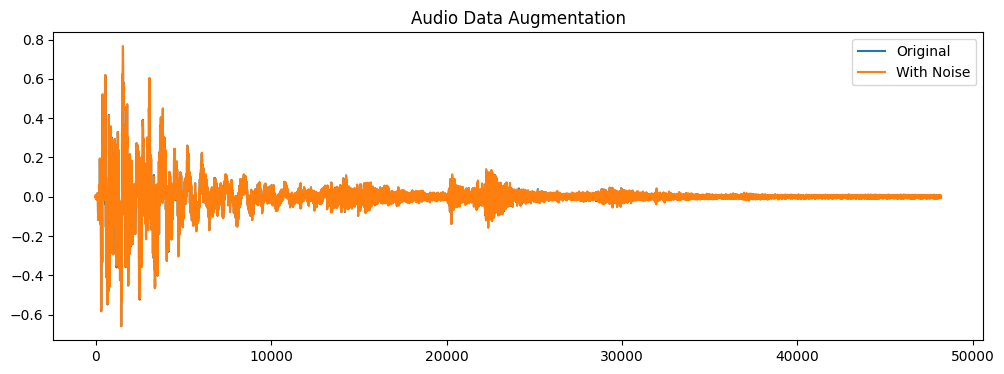

In [96]:
# Plot
plt.figure(figsize=(12, 4))

plt.plot(signal, label="Original")
plt.plot(augmented_signal, label="With Noise")

plt.legend()
plt.title("Audio Data Augmentation")

plt.show()

In [ ]:
# Save audio
sf.write("augmented_audio.wav", augmented_signal, sr)